# Part 1
In this part of the formative, I (Florence) focused on the Normal Distribution, also known as the Gaussian or continuous distribution. It is characterized by a bell-shaped curve that is symmetrical around the mean. This means most values cluster near the average, and the further you move away from the mean, the less likely the values become.

One of the key insights I gained is how the normal distribution is useful for modeling real-world continuous variables, such as pregnancy duration, height, or exam scores. For example, I used the distribution to analyze the length of human pregnancies, with a mean of 266 days and a standard deviation of 16. I calculated the proportion of pregnancies that last between 240 and 270 days, and visualized it using my Python implementation (no external math libraries).

I also explored the concept of the Z-score, which standardizes a value by expressing how many standard deviations it is from the mean. This is useful for comparing data points or finding probabilities using Z-tables or cumulative density calculations.

Through this task, I learned how to implement the normal distribution formula, estimate probabilities using numerical integration, and visualize the results using matplotlib. Overall, the normal distribution proved to be the most suitable model for this kind of data due to its continuous and symmetric nature

Estimated probability that a pregnancy lasts between 240 and 270 days: 0.5466


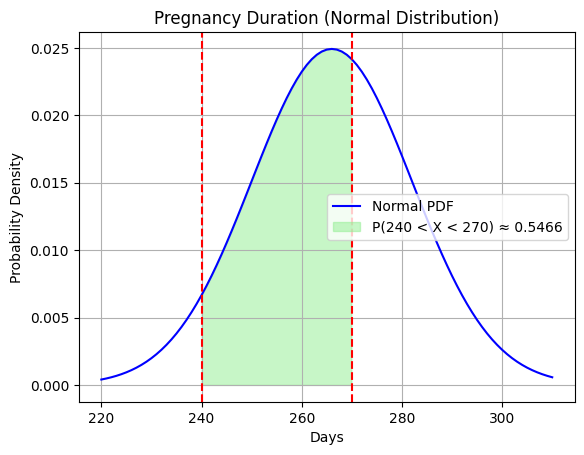

'This question is best solved using the normal distribution because pregnancy length is a continuous and naturally bell-shaped variable.\nIt wouldn’t fit a binomial model since we’re not counting successes or failures, and it’s not a Poisson or exponential case either because\nwe’re not measuring the number of events or time between random events — we’re measuring duration itself.'

In [1]:
#this is the real world question I am using
"""The length of human pregnancies from conception to birth approximates a normal distribution with a mean
of 266 days and a standard deviation of 16 days. What proportion of all pregnancies will last between 240
and 270 days (roughly between 8 and 9 months)?"""


# --------------------------
# Constants
PI = 3.141592653589793

# --------------------------
# Mathematical Functions
def factorial(n):
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result

def sqrt(x, tolerance=1e-10):
    guess = x / 2.0
    while abs(guess * guess - x) > tolerance:
        guess = (guess + x / guess) / 2.0
    return guess

def exp(x, terms=20):
    result = 1.0
    power = 1.0
    fact = 1.0
    for i in range(1, terms):
        power *= x
        fact *= i
        result += power / fact
    return result

# --------------------------
# Normal Distribution Core
def normal_pdf(x, mu, sigma):
    z = (x - mu) / sigma
    coefficient = 1 / (sigma * sqrt(2 * PI))
    exponent = exp(-0.5 * z ** 2)
    return coefficient * exponent

def generate_distribution_data(mu, sigma, start, end, step=1):
    x_values = []
    y_values = []
    x = start
    while x <= end:
        x_values.append(x)
        y_values.append(normal_pdf(x, mu, sigma))
        x += step
    return x_values, y_values

def approximate_probability(mu, sigma, a, b, step=0.1):
    x = a
    area = 0
    while x < b:
        height1 = normal_pdf(x, mu, sigma)
        height2 = normal_pdf(x + step, mu, sigma)
        trapezoid_area = (height1 + height2) * step / 2
        area += trapezoid_area
        x += step
    return area

# --------------------------
# Solve the Pregnancy Question
import matplotlib.pyplot as plt

def solve_pregnancy_question():
    mu = 266
    sigma = 16
    a = 240
    b = 270

    prob = approximate_probability(mu, sigma, a, b)
    print(f"Estimated probability that a pregnancy lasts between {a} and {b} days: {prob:.4f}")

    x_vals, y_vals = generate_distribution_data(mu, sigma, 220, 310)
    plt.plot(x_vals, y_vals, label='Normal PDF', color='blue')

    # Shade area between a and b
    x_shade = []
    y_shade = []
    x = a
    while x <= b:
        x_shade.append(x)
        y_shade.append(normal_pdf(x, mu, sigma))
        x += 0.1

    plt.fill_between(x_shade, y_shade, color='lightgreen', alpha=0.5, label=f'P({a} < X < {b}) ≈ {prob:.4f}')
    plt.axvline(x=a, color='red', linestyle='--')
    plt.axvline(x=b, color='red', linestyle='--')

    plt.title("Pregnancy Duration (Normal Distribution)")
    plt.xlabel("Days")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(True)
    plt.show()

# --------------------------
# Run only if this file is executed directly
if __name__ == "__main__":
    solve_pregnancy_question()

    
#Regarding if this question can be answered with the other distribution techniques
"""This question is best solved using the normal distribution because pregnancy length is a continuous and naturally bell-shaped variable.
It wouldn’t fit a binomial model since we’re not counting successes or failures, and it’s not a Poisson or exponential case either because
we’re not measuring the number of events or time between random events — we’re measuring duration itself."""


In [13]:
#from IPython.display import Image

# Image(filename='output.png')

# Part 2
This part demonstrates the application of Bayes’ Theorem to a real-world problem: predicting the likelihood of rain based on observed humidity levels.  
It uses given prior and conditional probabilities to calculate updated (posterior) probabilities for two scenarios: **high humidity and not-high humidity**.  

Step-by-step updates of prior, likelihood, marginal, and posterior values are shown to illustrate the reasoning process. 
 
The goal is to show how Bayesian inference helps refine predictions when new evidence is observed.  
This example highlights the practical use of probability in decision-making under uncertainty, such as in weather forecasting.


In [4]:
# Function to compute the marginal probability (the total probability of observing the evidence)
def compute_marginal(likelihood_rain, prior_rain, likelihood_no_rain, prior_no_rain):
    """
    Calculates the marginal probability of the evidence:
    P(Evidence) = P(Evidence | Rain) * P(Rain) + P(Evidence | No Rain) * P(No Rain)
    """
    return likelihood_rain * prior_rain + likelihood_no_rain * prior_no_rain

In [6]:
# Function to compute the posterior probability using Bayes' Theorem
def compute_posterior(prior_rain, likelihood_evidence_given_rain, likelihood_evidence_given_no_rain):
    """
    Applies Bayes' Theorem:
    P(Rain | Evidence) = [P(Evidence | Rain) * P(Rain)] / P(Evidence)
    Returns: posterior probability and marginal probability
    """
    prior_no_rain = 1 - prior_rain  # Since P(No Rain) = 1 - P(Rain)
    marginal = compute_marginal(
        likelihood_evidence_given_rain, prior_rain,
        likelihood_evidence_given_no_rain, prior_no_rain
    )
    posterior = (likelihood_evidence_given_rain * prior_rain) / marginal
    return posterior, marginal

In [7]:
# Display the results of Bayesian inference clearly
def display_results(condition, prior, likelihood_rain, likelihood_no_rain):
    """
    Wrapper to compute and print prior, likelihoods, marginal, and posterior nicely.
    """
    posterior, marginal = compute_posterior(prior, likelihood_rain, likelihood_no_rain)

    print(f"\n Condition: {condition}")
    print(f"Prior P(Rain): {prior}")
    print(f"Likelihood P({condition} | Rain): {likelihood_rain}")
    print(f"Likelihood P({condition} | No Rain): {likelihood_no_rain}")
    print(f"Marginal P({condition}): {round(marginal, 3)}")
    print(f"Posterior P(Rain | {condition}): {round(posterior, 3)}")


In [8]:
#  high humidity case

prior_rain = 0.3  # Prior belief that it rains
likelihood_high_given_rain = 0.8  # P(High Humidity | Rain)
likelihood_high_given_no_rain = 0.2  # P(High Humidity | No Rain)

display_results(
    condition="High Humidity",
    prior=prior_rain,
    likelihood_rain=likelihood_high_given_rain,
    likelihood_no_rain=likelihood_high_given_no_rain
)


 Condition: High Humidity
Prior P(Rain): 0.3
Likelihood P(High Humidity | Rain): 0.8
Likelihood P(High Humidity | No Rain): 0.2
Marginal P(High Humidity): 0.38
Posterior P(Rain | High Humidity): 0.632


In [9]:
# Not high humidity case

# Using complement probabilities for "not high humidity"
likelihood_low_given_rain = 1 - likelihood_high_given_rain  # = 0.2
likelihood_low_given_no_rain = 1 - likelihood_high_given_no_rain  # = 0.8

display_results(
    condition="Not High Humidity",
    prior=prior_rain,
    likelihood_rain=likelihood_low_given_rain,
    likelihood_no_rain=likelihood_low_given_no_rain
)


 Condition: Not High Humidity
Prior P(Rain): 0.3
Likelihood P(Not High Humidity | Rain): 0.19999999999999996
Likelihood P(Not High Humidity | No Rain): 0.8
Marginal P(Not High Humidity): 0.62
Posterior P(Rain | Not High Humidity): 0.097


**Bayesian inference** helped us update the chance of rain based on the observed humidity. It combined our initial belief (that it might rain) with new evidence (humidity level) to give a more accurate prediction. This shows how we can make better weather forecasts by updating our knowledge as we get new data.


# Part 3 & 4



This part demonstrates the Gradient Descent algorithm applied to a simple linear regression model. The section is divided into two main parts:

1.  **Part 3: Manual Calculations:** Performing step-by-step calculations of Gradient Descent updates for the parameters ($m$ and $b$).
2.  **Part 4:Code Implementation and Visualization:** Automating those steps with Python and visualizing the changes.

## Objective

Given a simple dataset, we aim to find the best-fit line using gradient descent to minimize the Mean Squared Error (MSE) by updating the slope (`m`) and y-intercept (`b`) iteratively.

---

## Manual Calculation Summary

We used the following gradient descent formulas:

- Predicted: \( \hat{y}_i = m x_i + b \)
- MSE: \( J(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \)
- Gradients:
  - mnew = mold − α(∂b\∂m)
  - \( \frac{\partial J}{\partial b} = -\frac{2}{n} \sum (y_i - \hat{y}_i) \)
- Updates:
  - \( m := m - \alpha \cdot \frac{\partial J}{\partial m} \)
  - \( b := b - \alpha \cdot \frac{\partial J}{\partial b} \)

We applied these formulas over four iterations, updating `m` and `b` each time.

---

In [10]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 3])
Y = np.array([3, 6])

m = -1
b = 1
alpha = 0.1
n = len(X)

m_history = [m]
b_history = [b]
error_history = []

print("--- Gradient Descent Simulation Setup ---")
print(f"Initial slope (m): {m}, Initial y-intercept (b): {b}")
print(f"Learning Rate (alpha): {alpha}")
print(f"Data Points: {list(zip(X, Y))}")
print(f"Number of data points (n): {n}\n")

def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

print("Setup complete. Ready to begin iterations.")

--- Gradient Descent Simulation Setup ---
Initial slope (m): -1, Initial y-intercept (b): 1
Learning Rate (alpha): 0.1
Data Points: [(np.int64(1), np.int64(3)), (np.int64(3), np.int64(6))]
Number of data points (n): 2

Setup complete. Ready to begin iterations.


In [11]:
num_iterations = 4

print(f"Starting Gradient Descent for {num_iterations} iterations...\n")

for iteration in range(1, num_iterations + 1):
    print(f"--- Iteration {iteration} ---")
    print(f"  Current parameters: m = {m:.4f}, b = {b:.4f}")

    y_pred = m * X + b
    print(f"  Computed predicted y_hat values: {y_pred}")

    errors = Y - y_pred
    print(f"  Individual errors (Y - y_hat): {errors}")

    current_mse = calculate_mse(Y, y_pred)
    error_history.append(current_mse)
    print(f"  Mean Squared Error (MSE): {current_mse:.4f}")

    sum_term_dm = np.sum(errors * X)
    dJ_dm = (-2 / n) * sum_term_dm
    print(f"  Gradient (dJ/dm): {dJ_dm:.4f}")

    sum_term_db = np.sum(errors)
    dJ_db = (-2 / n) * sum_term_db
    print(f"  Gradient (dJ/db): {dJ_db:.4f}")

    m = m - alpha * dJ_dm
    b = b - alpha * dJ_db
    print(f"  Updated parameters: m = {m:.4f}, b = {b:.4f}")

    m_history.append(m)
    b_history.append(b)

    print("-" * 40)

print("\n--- Gradient Descent Process Completed ---")
print(f"Final slope (m): {m:.4f}, Final intercept (b): {b:.4f}")

Starting Gradient Descent for 4 iterations...

--- Iteration 1 ---
  Current parameters: m = -1.0000, b = 1.0000
  Computed predicted y_hat values: [ 0 -2]
  Individual errors (Y - y_hat): [3 8]
  Mean Squared Error (MSE): 36.5000
  Gradient (dJ/dm): -27.0000
  Gradient (dJ/db): -11.0000
  Updated parameters: m = 1.7000, b = 2.1000
----------------------------------------
--- Iteration 2 ---
  Current parameters: m = 1.7000, b = 2.1000
  Computed predicted y_hat values: [3.8 7.2]
  Individual errors (Y - y_hat): [-0.8 -1.2]
  Mean Squared Error (MSE): 1.0400
  Gradient (dJ/dm): 4.4000
  Gradient (dJ/db): 2.0000
  Updated parameters: m = 1.2600, b = 1.9000
----------------------------------------
--- Iteration 3 ---
  Current parameters: m = 1.2600, b = 1.9000
  Computed predicted y_hat values: [3.16 5.68]
  Individual errors (Y - y_hat): [-0.16  0.32]
  Mean Squared Error (MSE): 0.0640
  Gradient (dJ/dm): -0.8000
  Gradient (dJ/db): -0.1600
  Updated parameters: m = 1.3400, b = 1.9160



--- Final Predictions ---
  x = 1 → Predicted y = 3.2304, Actual y = 3
  x = 3 → Predicted y = 5.8976, Actual y = 6
Final Mean Squared Error: 0.0318


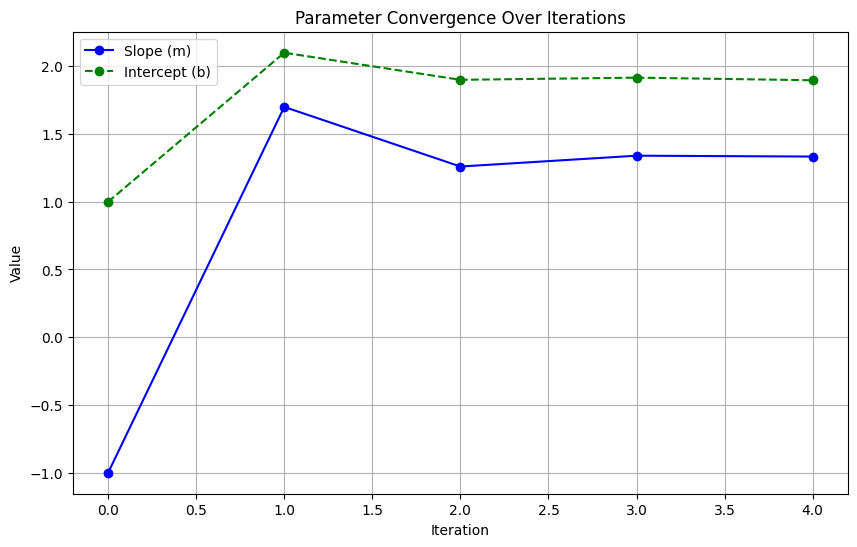

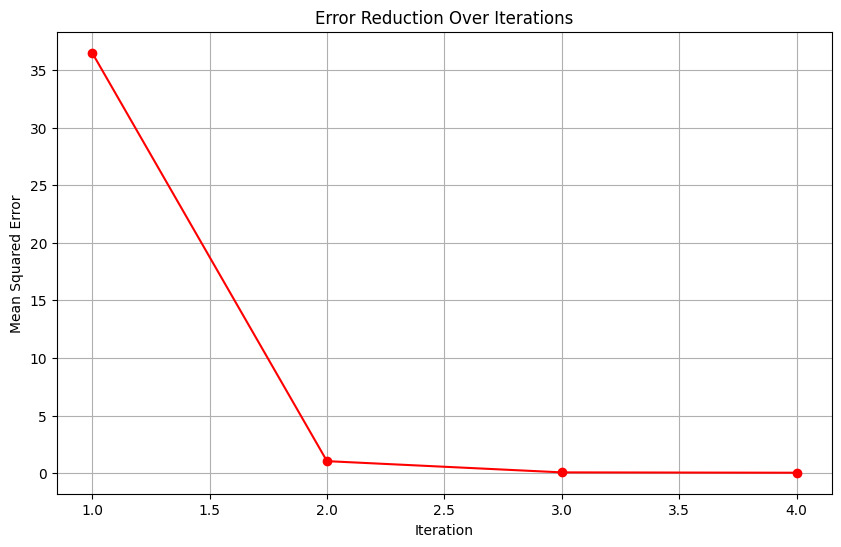


Plots generated. Observe parameter convergence and error reduction.


In [12]:
print("\n--- Final Predictions ---")
final_y_pred = m * X + b
for i, x_val in enumerate(X):
    print(f"  x = {x_val} → Predicted y = {final_y_pred[i]:.4f}, Actual y = {Y[i]}")

final_mse = calculate_mse(Y, final_y_pred)
print(f"Final Mean Squared Error: {final_mse:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(len(m_history)), m_history, 'o-', label='Slope (m)', color='blue')
plt.plot(range(len(b_history)), b_history, 'o--', label='Intercept (b)', color='green')
plt.title('Parameter Convergence Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_iterations + 1), error_history, 'o-', label='MSE', color='red')
plt.title('Error Reduction Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

print("\nPlots generated. Observe parameter convergence and error reduction.")